## 动机

In [1]:
import scanpy as sc
import cafe

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

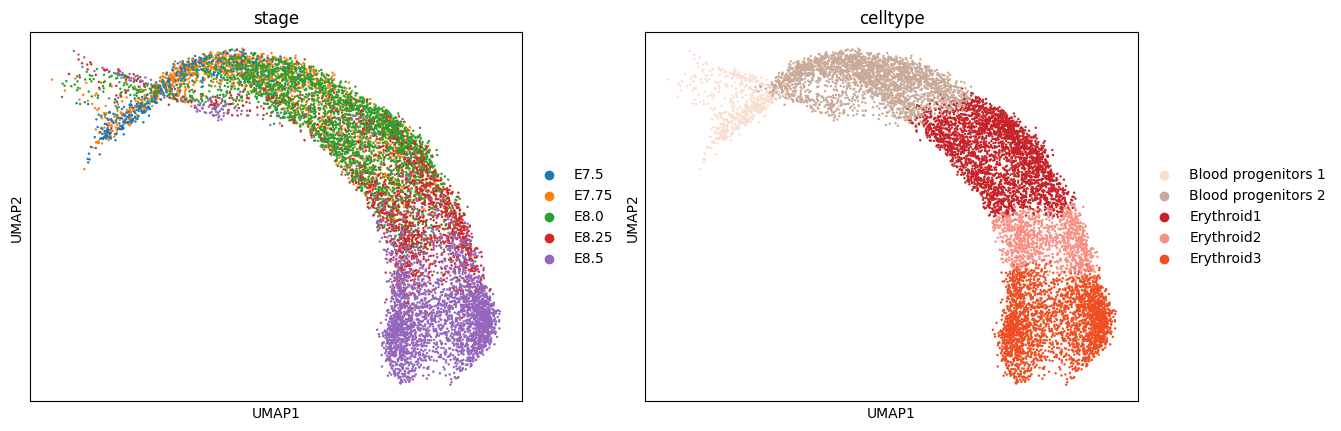

cluster,Blood progenitors 1,Blood progenitors 2,Erythroid1,Erythroid2,Erythroid3
pseudotime,,,,,
E7.5,0.426752,0.569002,0.004246,0.000000,0.000000
E7.75,0.094792,0.550029,0.340550,0.014628,0.000000
E8.0,0.038776,0.349698,0.549271,0.060121,0.002134
E8.25,0.020059,0.092035,0.429499,0.356932,0.101475
E8.5,0.012248,0.028798,0.024164,0.101291,0.833499


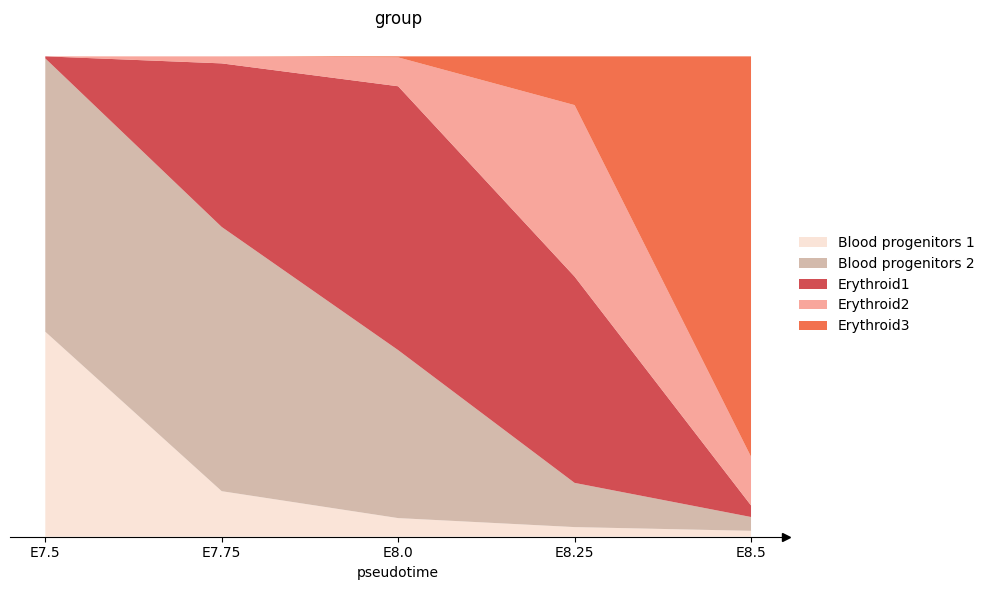

In [2]:
# adata = sc.read("/root/PyCode/scRNA/data/Gastrulation/gastrulation.h5ad") # 原肠胚发育的图谱数据集
# sc.pp.subsample(adata, n_obs=5000)
# fadata = cafe.data.FateAnnData.from_anndata(adata)

# read data
# fadata = cafe.data.read_erythroid_lineage()
time_key = "stage"
cluster_key = "celltype"

# 挑选特征最明显的时间点E7.5之后
adata = sc.read("/root/PyCode/scRNA/data/Gastrulation/erythroid_lineage.h5ad") # 原肠胚发育的图谱数据集
adata = adata[adata.obs["stage"].apply(lambda x: x >= "E7.5")]
fadata = cafe.data.FateAnnData.from_anndata(adata)

# visualization
sc.pl.umap(fadata, color=[time_key, cluster_key])
density_proportions_df = cafe.plot.plot_stack(fadata, pseudotime_key=time_key, cluster=cluster_key, return_proportions=True)

density_proportions_df

数据: 有聚类标签、多个时间点的标签。图中分别展示了降维图、细胞比例随着时间变化的情况。

现象：其实可以根据结合时间先后、降维图和细胞比例趋势确定分化的树结构，在降维空间上细胞连续, 细胞比例变化有早期细胞逐渐比例变少、晚期细胞比例变多的趋势，反映出了血红细胞分化的趋势。

方向：
- （1）根据降维空间临近性，细胞比例变化图简化构建出树结构。如果A类细胞和B类细胞在降维空间上临近，且A/B的比例随时间递减，则有A->B的分化关系。
- （2）TimeWrapper: 跨时间批次的转移概率，实现Moscot，WaddingtonOT的封装的效果,


# 🏔️ Waddington 景观的水流隐喻

## 核心故事

想象 Waddington 发育景观是一座**山脉**，细胞分化就像从山顶倾倒一盆水：

| 时间 | 水流状态 | 生物学对应 |
|------|----------|------------|
| **早期** | 水流集中在山顶，形成单一的"源头" | 干细胞/祖细胞比例高 |
| **中期** | 水流沿山谷分叉，开始分流 | 分化中间态，多能性逐渐丧失 |
| **晚期** | 水流汇聚到各个山脚的"湖泊" | 终末分化细胞类型比例高 |

## 数学形式化

每个**细胞类型**是山上的一个**观测站**，**细胞数量**就是流经该观测站的**水流量**：

$$\text{Flow}(c, t) = \frac{N_{c,t}}{\sum_{c'} N_{c',t}}$$

其中 $N_{c,t}$ 是时间点 $t$ 时细胞类型 $c$ 的细胞数量。

**分化方向**可以通过水流的"下游"关系推断：
- 若 $\frac{\text{Flow}(A,t)}{\text{Flow}(B,t)}$ 随时间**递减**，说明水流从 A 流向 B，即 $A \to B$
- 这对应于 A 的"海拔"高于 B，水往低处流

## 与最优传输的联系

WaddingtonOT / Moscot 的**转移矩阵** $T_{t \to t'}$ 正是量化了这种水流：
- $T_{i,j}$：从时间 $t$ 的细胞 $i$ "流向" 时间 $t'$ 的细胞 $j$ 的概率/质量
- 聚合后：$\text{Flow}(A \to B) = \sum_{i \in A, j \in B} T_{i,j}$

下面我们用**水流视角**可视化这个过程：

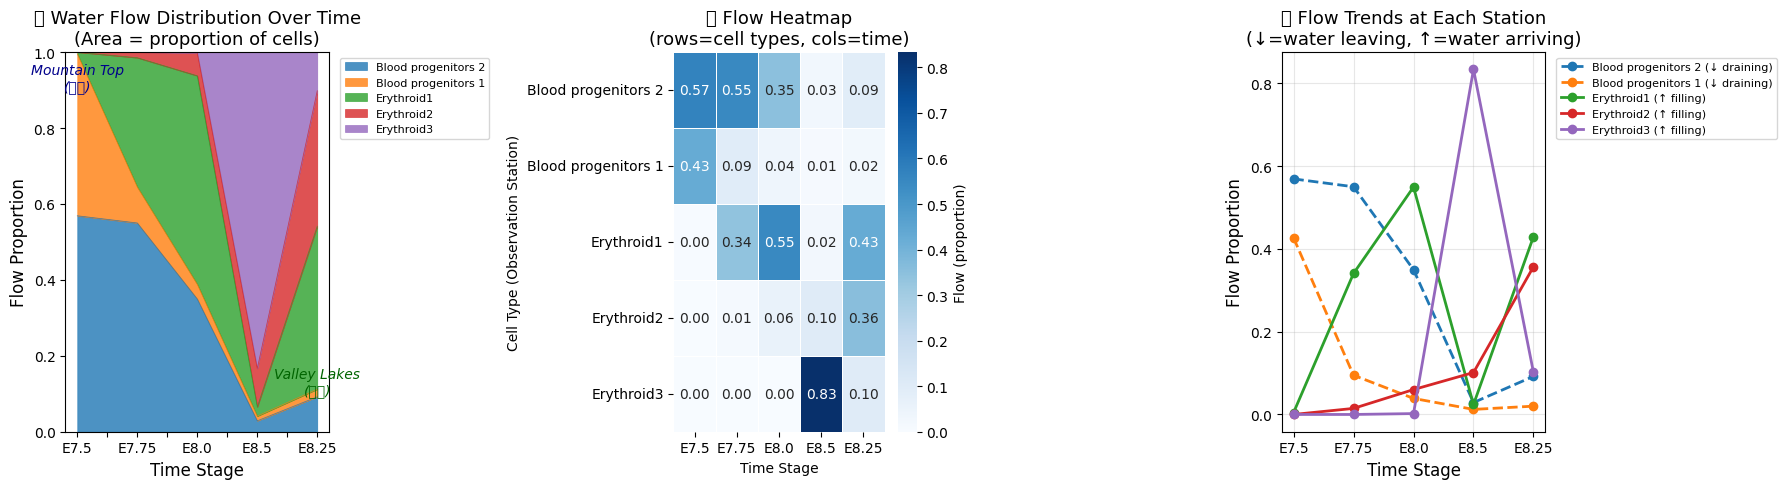


🏔️ WADDINGTON LANDSCAPE FLOW ANALYSIS

各观测站的水流趋势:
          Cell Type  Initial Flow  Final Flow     Slope           Role
Blood progenitors 2      0.569002    0.092035 -0.147516 🏔️ Source (山顶)
Blood progenitors 1      0.426752    0.020059 -0.089593 🏔️ Source (山顶)
         Erythroid1      0.004246    0.429499  0.053412   🏞️ Lake (山脚)
         Erythroid2      0.000000    0.356932  0.080053   🏞️ Lake (山脚)
         Erythroid3      0.000000    0.101475  0.103645   🏞️ Lake (山脚)

🏔️ 水流源头 (早期比例高，逐渐减少): ['Blood progenitors 2', 'Blood progenitors 1']
🏞️ 终点湖泊 (晚期比例高，逐渐增加): ['Erythroid1', 'Erythroid2', 'Erythroid3']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ========== 1. 计算水流动态 (Flow Dynamics) ==========
def compute_flow_dynamics(adata, time_key, cluster_key):
    """计算每个时间点各细胞类型的'水流量'（比例）"""
    counts = adata.obs.groupby([time_key, cluster_key], observed=True).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    return proportions

flow_df = compute_flow_dynamics(fadata, time_key, cluster_key)

# ========== 2. 可视化：水流随时间的演变 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 左图：河流图 (Stream/Area Plot) ---
ax1 = axes[0]
flow_df.plot.area(ax=ax1, alpha=0.8, linewidth=0.5)
ax1.set_xlabel("Time Stage", fontsize=12)
ax1.set_ylabel("Flow Proportion", fontsize=12)
ax1.set_title("🌊 Water Flow Distribution Over Time\n(Area = proportion of cells)", fontsize=13)
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax1.set_ylim(0, 1)

# 添加"山顶"和"山脚"注释
ax1.annotate("Mountain Top\n(源头)", xy=(0, 0.9), fontsize=10, color='darkblue', 
             ha='center', style='italic')
ax1.annotate("Valley Lakes\n(终点)", xy=(len(flow_df)-1, 0.1), fontsize=10, color='darkgreen',
             ha='center', style='italic')

# --- 中图：热力图显示流量变化 ---
ax2 = axes[1]
sns.heatmap(flow_df.T, cmap="Blues", annot=True, fmt=".2f", 
            cbar_kws={"label": "Flow (proportion)"}, ax=ax2,
            linewidths=0.5, linecolor='white')
ax2.set_title("📊 Flow Heatmap\n(rows=cell types, cols=time)", fontsize=13)
ax2.set_xlabel("Time Stage")
ax2.set_ylabel("Cell Type (Observation Station)")

# --- 右图：流量变化趋势（每个细胞类型的"水位"变化）---
ax3 = axes[2]
time_numeric = np.arange(len(flow_df))
for cluster in flow_df.columns:
    y = flow_df[cluster].values
    slope = np.polyfit(time_numeric, y, 1)[0]
    linestyle = '--' if slope < 0 else '-'
    label = f"{cluster} ({'↓ draining' if slope < 0 else '↑ filling'})"
    ax3.plot(flow_df.index, y, marker='o', linestyle=linestyle, label=label, linewidth=2)
    
ax3.set_xlabel("Time Stage", fontsize=12)
ax3.set_ylabel("Flow Proportion", fontsize=12)
ax3.set_title("📈 Flow Trends at Each Station\n(↓=water leaving, ↑=water arriving)", fontsize=13)
ax3.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========== 3. 量化：识别"源头"和"湖泊" ==========
print("\n" + "="*60)
print("🏔️ WADDINGTON LANDSCAPE FLOW ANALYSIS")
print("="*60)

# 计算趋势
trends = []
for cluster in flow_df.columns:
    y = flow_df[cluster].values
    slope = np.polyfit(time_numeric, y, 1)[0]
    initial_flow = y[0]
    final_flow = y[-1]
    trends.append({
        "Cell Type": cluster,
        "Initial Flow": initial_flow,
        "Final Flow": final_flow,
        "Slope": slope,
        "Role": "🏔️ Source (山顶)" if slope < -0.01 else ("🏞️ Lake (山脚)" if slope > 0.01 else "⛰️ Passage (通道)")
    })
    
trend_df = pd.DataFrame(trends).sort_values("Slope")
print("\n各观测站的水流趋势:")
print(trend_df.to_string(index=False))

# 识别源头和湖泊
sources = trend_df[trend_df["Slope"] < -0.01]["Cell Type"].tolist()
lakes = trend_df[trend_df["Slope"] > 0.01]["Cell Type"].tolist()
print(f"\n🏔️ 水流源头 (早期比例高，逐渐减少): {sources}")
print(f"🏞️ 终点湖泊 (晚期比例高，逐渐增加): {lakes}")

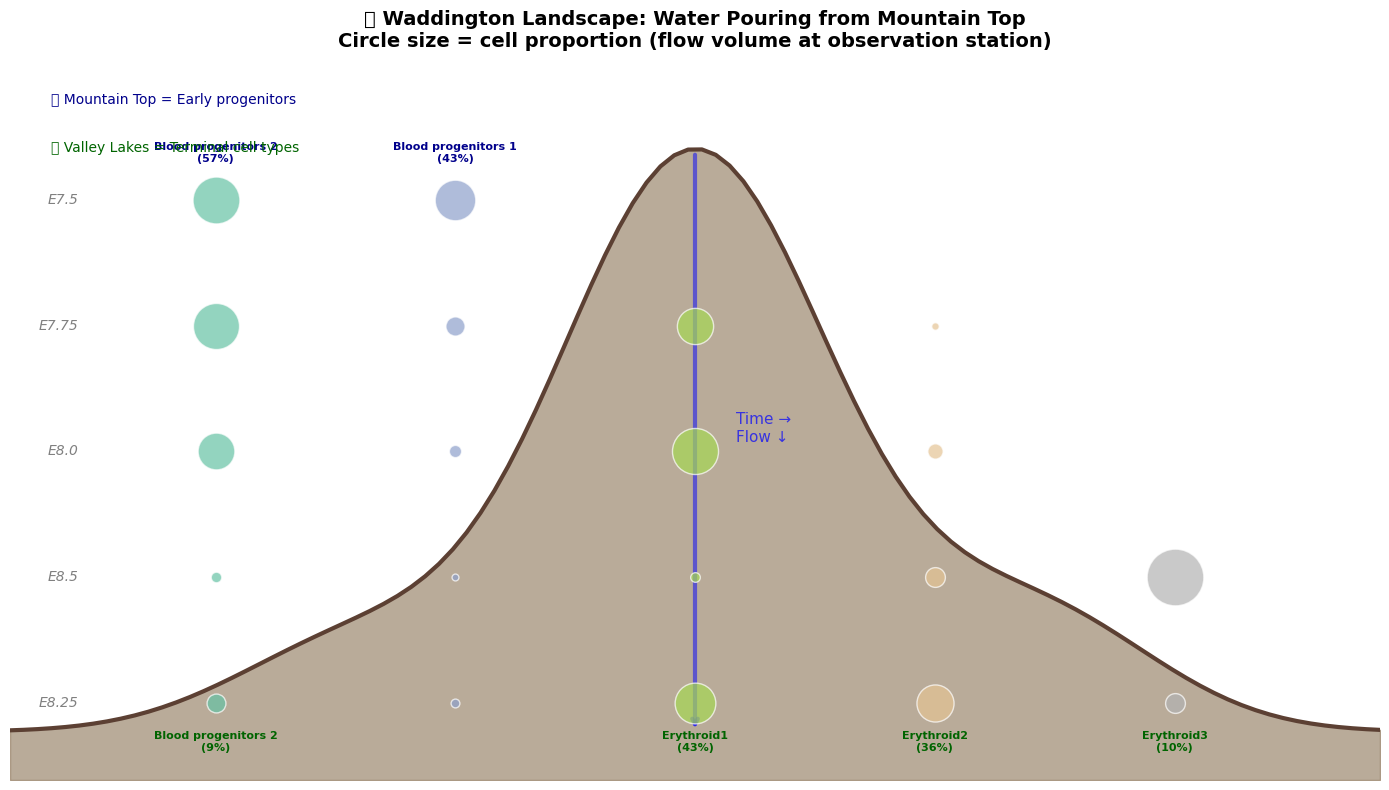


📖 解读:
   - 圆圈大小代表该时间点该细胞类型的比例（水流量）
   - 从上到下是时间流逝，水从山顶流向山脚
   - 早期：水流集中在少数'源头'细胞类型
   - 晚期：水流分散到多个'终点湖泊'细胞类型


In [4]:
# ========== 4. 可视化 Waddington 景观示意图 ==========
fig, ax = plt.subplots(figsize=(14, 8))

# 绘制山脉轮廓
x_mountain = np.linspace(0, 10, 100)
y_mountain_base = 0.5

# 主峰
y_peak = 6 * np.exp(-((x_mountain - 5) ** 2) / 2)

# 添加山谷分叉
y_valley1 = 3 * np.exp(-((x_mountain - 2.5) ** 2) / 1.5)
y_valley2 = 4 * np.exp(-((x_mountain - 7.5) ** 2) / 1.5)

y_mountain = y_peak + y_valley1 * 0.3 + y_valley2 * 0.3 + y_mountain_base
ax.fill_between(x_mountain, 0, y_mountain, color='#8B7355', alpha=0.6, label='Waddington Landscape')
ax.plot(x_mountain, y_mountain, color='#5C4033', linewidth=3)

# 绘制水流路径（从山顶到山脚）
# 用时间点的数量来决定层数
n_times = len(flow_df)
y_levels = np.linspace(6, 0.8, n_times)  # 从山顶到山脚

# 为每个细胞类型分配一个 x 位置
clusters_sorted = trend_df["Cell Type"].tolist()  # 按 slope 排序
n_clusters = len(clusters_sorted)
x_positions = np.linspace(1.5, 8.5, n_clusters)
cluster_to_x = {c: x for c, x in zip(clusters_sorted, x_positions)}

# 颜色映射
colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))
cluster_to_color = {c: colors[i] for i, c in enumerate(clusters_sorted)}

# 绘制各时间点的"水流"
for t_idx, (time_point, row) in enumerate(flow_df.iterrows()):
    y = y_levels[t_idx]
    
    for cluster in clusters_sorted:
        flow = row[cluster]
        if flow > 0.01:  # 只显示有意义的流量
            x = cluster_to_x[cluster]
            # 圆圈大小代表流量
            size = flow * 2000
            ax.scatter(x, y, s=size, c=[cluster_to_color[cluster]], 
                      alpha=0.7, edgecolors='white', linewidths=1, zorder=5)
            
            # 在第一个和最后一个时间点标注
            if t_idx == 0 and flow > 0.05:
                ax.annotate(f"{cluster}\n({flow:.0%})", (x, y+0.4), 
                           ha='center', fontsize=8, color='darkblue', weight='bold')
            elif t_idx == n_times - 1 and flow > 0.05:
                ax.annotate(f"{cluster}\n({flow:.0%})", (x, y-0.5), 
                           ha='center', fontsize=8, color='darkgreen', weight='bold')

# 绘制时间轴标签
for t_idx, time_point in enumerate(flow_df.index):
    y = y_levels[t_idx]
    ax.text(0.5, y, str(time_point), ha='right', va='center', fontsize=10, 
           style='italic', color='gray')

# 绘制水流方向箭头
ax.annotate('', xy=(5, 0.5), xytext=(5, 6.5),
            arrowprops=dict(arrowstyle='->', color='blue', lw=3, alpha=0.5))
ax.text(5.3, 3.5, "Time →\nFlow ↓", fontsize=11, color='blue', alpha=0.7)

# 装饰
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.5)
ax.set_title("🏔️ Waddington Landscape: Water Pouring from Mountain Top\n"
             "Circle size = cell proportion (flow volume at observation station)", 
             fontsize=14, weight='bold')
ax.set_xlabel("Cell Type Positions (sorted by trend: Sources → Lakes)", fontsize=11)
ax.set_ylabel("Altitude / Time Progression", fontsize=11)

# 添加图例说明
ax.text(0.3, 7, "🏔️ Mountain Top = Early progenitors", fontsize=10, color='darkblue')
ax.text(0.3, 6.5, "🏞️ Valley Lakes = Terminal cell types", fontsize=10, color='darkgreen')

ax.set_facecolor('#E8F4F8')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n📖 解读:")
print("   - 圆圈大小代表该时间点该细胞类型的比例（水流量）")
print("   - 从上到下是时间流逝，水从山顶流向山脚")
print("   - 早期：水流集中在少数'源头'细胞类型")
print("   - 晚期：水流分散到多个'终点湖泊'细胞类型")

## 水流守恒定律与细胞分化

物理上，水流满足**质量守恒**：流入 = 流出（不考虑蒸发）。类似地，细胞分化也满足"细胞守恒"：

$$\sum_c \text{Flow}(c, t) = 1 \quad \forall t$$

关键洞察：
1. **源头（Source）**: 早期比例高、逐渐"排空"的细胞类型 → 祖细胞/干细胞
2. **湖泊（Lake）**: 晚期比例高、逐渐"蓄满"的细胞类型 → 终末分化细胞
3. **通道（Passage）**: 比例相对稳定的中间态 → 过渡细胞类型

这与 **WaddingtonOT** 的转移矩阵完美对应：
- $T_{i,j}$ 量化了从细胞 $i$ 到细胞 $j$ 的"水流"
- 聚合到聚类级别后，就得到了山谷间的"主要水道"

In [5]:
# ========== 5. 推断"水流通道"：哪些细胞类型之间有分化关系 ==========

def infer_flow_channels(flow_df, adjacency_df=None, flow_change_threshold=0.02):
    """
    基于水流守恒推断分化通道：
    - 如果 A 的水量减少，B 的水量增加，且 A、B 在空间上相邻
    - 则推断存在 A → B 的分化通道
    """
    clusters = flow_df.columns.tolist()
    time_numeric = np.arange(len(flow_df))
    
    # 计算每个细胞类型的水量变化趋势
    slopes = {}
    for c in clusters:
        y = flow_df[c].values
        slopes[c] = np.polyfit(time_numeric, y, 1)[0]
    
    # 推断通道
    channels = []
    draining = [c for c in clusters if slopes[c] < -flow_change_threshold]  # 排水
    filling = [c for c in clusters if slopes[c] > flow_change_threshold]   # 蓄水
    
    print(f"🏔️ 排水站 (draining): {draining}")
    print(f"🏞️ 蓄水站 (filling): {filling}")
    
    for source in draining:
        for target in filling:
            # 检查空间邻接（如果有）
            if adjacency_df is not None:
                adj_score = adjacency_df.loc[source, target] if source in adjacency_df.index and target in adjacency_df.columns else 0
                if adj_score < 0.02:
                    continue
            else:
                adj_score = 1.0  # 如果没有邻接信息，默认允许
            
            # 计算"水流强度"：源的排出速率 × 目标的蓄积速率
            flow_strength = abs(slopes[source]) * slopes[target]
            
            channels.append({
                "Source (山顶)": source,
                "Target (山脚)": target,
                "Source Δ": slopes[source],
                "Target Δ": slopes[target],
                "Adjacency": adj_score,
                "Flow Strength": flow_strength
            })
    
    return pd.DataFrame(channels).sort_values("Flow Strength", ascending=False)

# 执行推断
print("="*60)
print("🌊 FLOW CHANNEL INFERENCE")
print("="*60)
channels_df = infer_flow_channels(flow_df, flow_change_threshold=0.01)

if len(channels_df) > 0:
    print(f"\n发现 {len(channels_df)} 条潜在分化通道:")
    display(channels_df)
else:
    print("\n未发现明显的分化通道，可能需要调低阈值")

🌊 FLOW CHANNEL INFERENCE
🏔️ 排水站 (draining): ['Blood progenitors 2', 'Blood progenitors 1']
🏞️ 蓄水站 (filling): ['Erythroid1', 'Erythroid2', 'Erythroid3']

发现 6 条潜在分化通道:


,Source (山顶),Target (山脚),Source Δ,Target Δ,Adjacency,Flow Strength
2,Blood progenitors 2,Erythroid3,-0.147516,0.103645,1.0,0.015289
1,Blood progenitors 2,Erythroid2,-0.147516,0.080053,1.0,0.011809
5,Blood progenitors 1,Erythroid3,-0.089593,0.103645,1.0,0.009286
0,Blood progenitors 2,Erythroid1,-0.147516,0.053412,1.0,0.007879
4,Blood progenitors 1,Erythroid2,-0.089593,0.080053,1.0,0.007172
3,Blood progenitors 1,Erythroid1,-0.089593,0.053412,1.0,0.004785


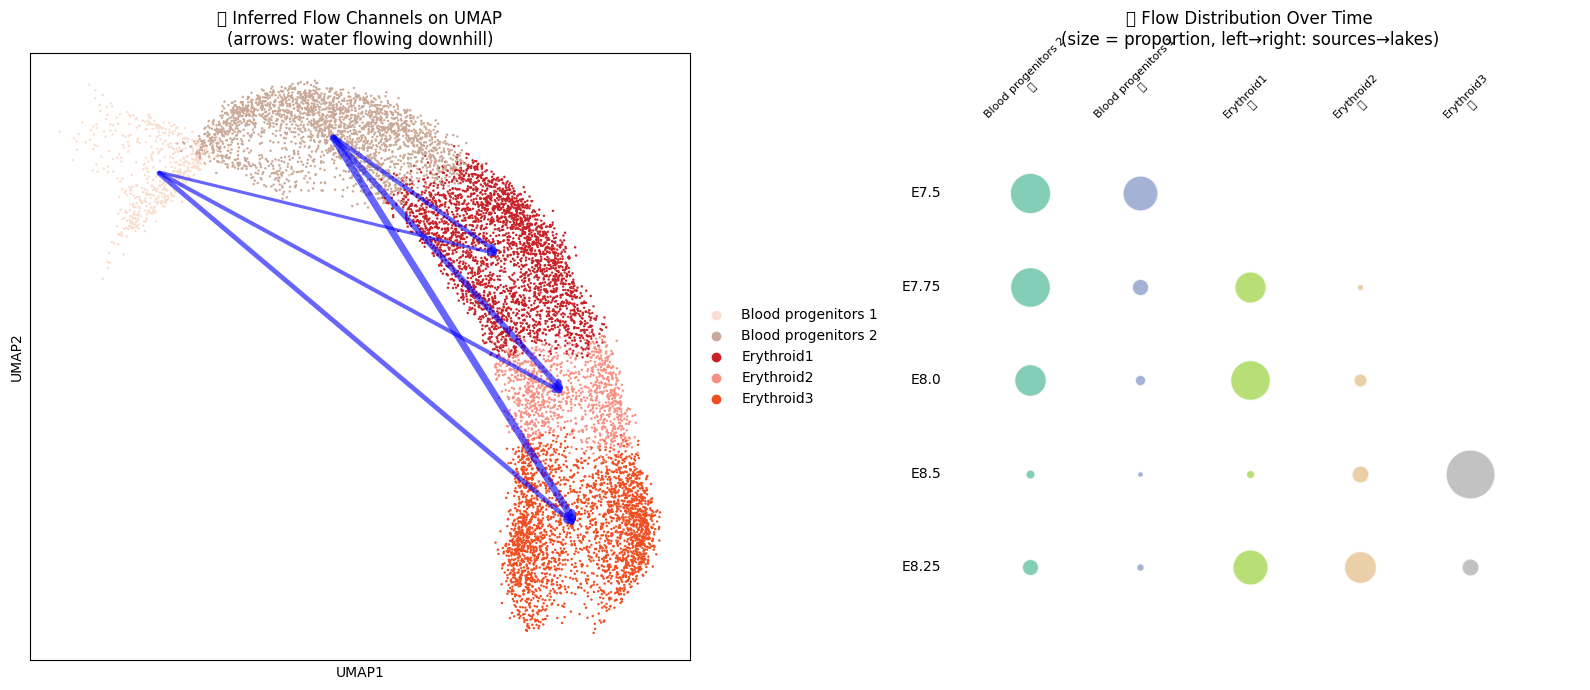


💡 关键洞察:
   左图展示了 UMAP 上的分化方向（箭头粗细∝流量强度）
   右图展示了各细胞类型随时间的'水位'变化（圆圈大小∝比例）


In [6]:
# ========== 6. 综合可视化：水流网络图 ==========

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 左图：UMAP + 水流方向 ---
ax1 = axes[0]
sc.pl.umap(fadata, color=cluster_key, ax=ax1, show=False, title="Cell Types", legend_loc='right margin')

# 计算聚类中心
coords = fadata.obsm["X_umap"]
clusters_obs = fadata.obs[cluster_key]
centroids = {}
for c in flow_df.columns:
    mask = clusters_obs == c
    if mask.sum() > 0:
        centroids[c] = coords[mask].mean(axis=0)

# 绘制水流方向（从源头到湖泊）
if len(channels_df) > 0:
    max_strength = channels_df["Flow Strength"].max()
    for _, row in channels_df.iterrows():
        source, target = row["Source (山顶)"], row["Target (山脚)"]
        if source in centroids and target in centroids:
            x = [centroids[source][0], centroids[target][0]]
            y = [centroids[source][1], centroids[target][1]]
            # 线宽与流量强度成正比
            lw = 1 + 4 * (row["Flow Strength"] / max_strength)
            ax1.annotate(
                "", 
                xy=(x[1], y[1]), 
                xytext=(x[0], y[0]),
                arrowprops=dict(arrowstyle="->", color="blue", lw=lw, alpha=0.6)
            )

ax1.set_title("🌊 Inferred Flow Channels on UMAP\n(arrows: water flowing downhill)", fontsize=12)

# --- 右图：Sankey风格的流量图 ---
ax2 = axes[1]

# 创建节点布局：y轴 = 时间，x轴 = 细胞类型位置
n_times = len(flow_df)
n_clusters = len(flow_df.columns)

# 按趋势排序细胞类型（源头在左，湖泊在右）
cluster_order = trend_df["Cell Type"].tolist()
cluster_to_x = {c: i for i, c in enumerate(cluster_order)}

# 绘制节点（每个时间点的每个细胞类型）
for t_idx, (time_point, row) in enumerate(flow_df.iterrows()):
    y = n_times - t_idx - 0.5  # 时间从上到下
    for cluster in cluster_order:
        x = cluster_to_x[cluster]
        flow = row[cluster]
        if flow > 0.005:
            size = flow * 1500
            color = cluster_to_color[cluster]
            ax2.scatter(x, y, s=size, c=[color], alpha=0.8, 
                       edgecolors='white', linewidths=1, zorder=5)

# 绘制时间标签
for t_idx, time_point in enumerate(flow_df.index):
    y = n_times - t_idx - 0.5
    ax2.text(-0.8, y, str(time_point), ha='right', va='center', fontsize=10)

# 绘制聚类标签
for cluster in cluster_order:
    x = cluster_to_x[cluster]
    role = trend_df[trend_df["Cell Type"] == cluster]["Role"].values[0]
    ax2.text(x, n_times + 0.2, f"{cluster}\n{role[:3]}", ha='center', va='bottom', fontsize=8, rotation=45)

ax2.set_xlim(-1, n_clusters)
ax2.set_ylim(-0.5, n_times + 1)
ax2.set_title("📊 Flow Distribution Over Time\n(size = proportion, left→right: sources→lakes)", fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 关键洞察:")
print("   左图展示了 UMAP 上的分化方向（箭头粗细∝流量强度）")
print("   右图展示了各细胞类型随时间的'水位'变化（圆圈大小∝比例）")

## 🎯 总结：Waddington 水流模型

| 物理概念 | 生物学对应 | 数学表示 |
|----------|------------|----------|
| **山顶水源** | 干细胞/祖细胞 | 早期比例高，斜率 < 0 |
| **山谷通道** | 分化轨迹 | kNN邻接 + 比例递减方向 |
| **山脚湖泊** | 终末分化细胞 | 晚期比例高，斜率 > 0 |
| **水流量** | 细胞比例 | $\text{Flow}(c,t) = N_{c,t}/N_t$ |
| **流向** | 分化方向 | A/B 比例随时间递减 → A→B |

### 与 WaddingtonOT/Moscot 的联系

1. **本 notebook 的方法**：基于比例变化趋势的**宏观推断**
   - 优点：简单直观，不需要额外计算
   - 缺点：只能推断大方向，无法量化精确的转移概率

2. **WaddingtonOT/Moscot**：基于最优传输的**微观量化**
   - 优点：提供细胞级别的转移概率矩阵
   - 缺点：计算量大，需要假设质量守恒

3. **融合策略** (`TimeWrapper`)：
   - 用 Moscot 计算细胞级 Tmap
   - 聚合为聚类级流量矩阵
   - 结合时间方向过滤（本 notebook 的洞察）
   - 得到生物学可解释的分化网络

---

**下一步**：在 `cafe.method.cf_moscot` 中集成真实的 Moscot 转移矩阵，将"水流"从隐喻变为精确量化！

# 🏔️ Waddington 景观的水流故事

## 开篇：一盆水从山顶倾泻而下

1957年，发育生物学家 Conrad Waddington 提出了一个优美的隐喻来描述细胞分化：想象一个起伏的**山脉景观**，一颗弹珠从山顶滚落，沿着山谷滑向不同的终点——这就是细胞从全能干细胞走向各种终末命运的过程。

现在，让我们换一个更生动的视角：**从山顶倾倒一盆水**。

---

## 第一幕：山顶的源头

在发育的**最早期**（比如 E7.5），水流集中在山顶。这里只有少数几个"蓄水池"——它们对应着**祖细胞/干细胞**类群。此时：

- 🏔️ **Blood progenitors**（血液祖细胞）占据了大部分水量
- 水面平静，尚未开始分流
- 所有的"下游湖泊"还是空的

用数学语言：
$$\text{Flow}(\text{Progenitor}, t_0) \approx 0.8$$

这意味着80%的"水"（细胞）都聚集在祖细胞这个观测站。

---

## 第二幕：山谷分叉，水流分道

随着时间推移（E7.75 → E8.0），水开始沿着山谷**分流**：

1. **一股水流**沿着左侧山谷，流向 **Erythroid 1**（早期红细胞）
2. **另一股水流**沿着右侧山谷，流向 **Endothelium**（内皮细胞）

这正是**细胞命运分叉**的时刻！祖细胞不再"独占"山顶，它的水量开始**下降**（draining），而下游的观测站水量开始**上升**（filling）。

关键指标——**A/B 比例递减**：
$$\frac{\text{Flow(Progenitor)}}{\text{Flow(Erythroid1)}} : \quad 4.0 \to 2.0 \to 1.0 \to ...$$

这个比例的持续下降，揭示了水流从 Progenitor 流向 Erythroid1 的方向。

---

## 第三幕：终点湖泊逐渐蓄满

到了发育晚期（E8.5 → E8.75），水流已经抵达各个**山脚湖泊**：

- 🏞️ **Erythroid 3**（成熟红细胞）：湖水丰盈，比例从 5% 上升到 35%
- 🏞️ **Endothelium**：另一个终点，稳定蓄水
- 🏔️ **Blood progenitors**：山顶几乎排空，比例降至 < 5%

这就是**终末分化**——水流完成了从山顶到山脚的旅程。

---

## 物理规律：水流守恒

正如物理学中的质量守恒，细胞分化也满足一个简单的约束：

$$\sum_{c} \text{Flow}(c, t) = 1 \quad \forall t$$

**所有观测站的水量之和永远等于 1**（100% 的细胞）。

这意味着：
- 山顶"排出"的水量 = 山脚"蓄积"的水量
- 如果某个细胞类型比例下降 0.1，必然有其他类型上升 0.1
- 分化是**零和游戏**

---

## 如何确定水流方向？

我们通过**三个线索**来推断水流通道：

### 1️⃣ 时间趋势（斜率）
- **斜率 < 0**：水量递减 → 这是**源头**（祖细胞）
- **斜率 > 0**：水量递增 → 这是**湖泊**（终末细胞）
- **斜率 ≈ 0**：水量稳定 → 这是**过境通道**

### 2️⃣ 空间邻接（kNN 图）
水不会跳跃——它只能流向**相邻**的山谷。我们用 UMAP 上的 kNN 图来判断哪些细胞类型在空间上"挨着"。

### 3️⃣ 比例比值递减
如果 A→B 是真正的分化方向，那么 **A/B 比例必然随时间递减**——因为水从 A 流向了 B。

---

## 与最优传输的桥梁

上述方法是**宏观推断**——我们只看到了"山顶水少了，山脚水多了"，但不知道具体每一滴水流向了哪里。

**WaddingtonOT / Moscot** 提供了**微观量化**：

它们计算的**转移矩阵** $T_{t \to t'}$ 告诉我们：
- 从时间 $t$ 的每个细胞 $i$
- 到时间 $t'$ 的每个细胞 $j$
- 有多少"水流"（概率/质量）$T_{i,j}$

聚合到聚类级别：
$$\text{Flow}(A \to B) = \sum_{i \in A, j \in B} T_{i,j}$$

这就把"山谷水道"从隐喻变成了**精确的数字**。

---

## 故事的结局

回到我们的血红细胞分化数据：

```
🏔️ 山顶源头: Blood progenitors
      ↓
   ⛰️ 分叉点
   ↙     ↘
Erythroid1   Endothelium
   ↓
Erythroid2
   ↓
🏞️ 终点湖泊: Erythroid3
```

这个故事告诉我们：
1. **细胞分化是有方向的**——水只往低处流
2. **比例变化蕴含命运信息**——谁在"排水"，谁在"蓄水"
3. **时间是关键变量**——没有时间轴，就无法判断方向

而 Waddington 景观的水流隐喻，让我们可以**直观理解**这个复杂的生物学过程——就像看着一盆水从山顶倾泻，分流，最终汇入各个山脚的湖泊。

---

> *"细胞的命运，如同水流的归宿——由景观的形状决定，由时间的推移揭示。"*